# 06. Fuel Cost Impact

## Business Question

Was the rise in fuel prices a critical factor affecting business viability?

### Methodology Note

Fuel price trend, company performance, and the freight-rate comparison use the full period (Jul 2022 - Oct 2024) - this question is about a trend over time, not a snapshot. Client- and route-level exposure analysis use only clients/trips active in 2024, consistent with `05_client_profitability.ipynb`, to keep the comparison fair across different tenures and avoid mixing incomplete years.

Fuel Intensity (liters consumed per 1,000 UAH of revenue) is used for the exposure analysis sections rather than fuel cost share - fuel cost share is mathematically the inverse of gross margin (`fuel_cost_uah / revenue_uah = 1 - gross_margin_pct/100`) and would simply reproduce the margin ranking from `05_client_profitability.ipynb`. Fuel Intensity is a physical measure of exposure to further fuel price increases, independent of the current tariff - a different and complementary question.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 5)

In [2]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True,
    future=True
)

try:
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
    print("Successfully connected to MySQL.")
except Exception as e:
    print(f"Connection failed:\n{e}")

Successfully connected to MySQL.


### Data Preparation

In [3]:
trips = pd.read_sql(
    text("SELECT * FROM trip_analytical_dataset"),
    engine,
    parse_dates=["date_departure", "date_arrival"]
)

fuel_batches = pd.read_sql(
    text("SELECT * FROM fuel_batches"),
    engine,
    parse_dates=["purchase_date"]
)

print(f"Trips loaded: {len(trips):,}")
print(f"Fuel batches loaded: {len(fuel_batches):,}")

Trips loaded: 4,925
Fuel batches loaded: 16


## Dataset Validation

In [4]:
valid_trips = trips.dropna(subset=["revenue_uah", "fuel_cost_uah"])

print(f"Date range: {trips['date_departure'].min().date()} - {trips['date_departure'].max().date()}")
print(f"Total trips: {len(trips):,}")
print(f"Valid trips (revenue + fuel cost present): {len(valid_trips):,}")
print(f"Fuel batches: {len(fuel_batches):,}")
print(f"Fuel batches date range: {fuel_batches['purchase_date'].min().date()} - {fuel_batches['purchase_date'].max().date()}")
print(f"Duplicate batch_id: {fuel_batches['batch_id'].duplicated().sum()}")

Date range: 2022-07-01 - 2024-10-31
Total trips: 4,925
Valid trips (revenue + fuel cost present): 4,827
Fuel batches: 16
Fuel batches date range: 2022-07-01 - 2024-09-24
Duplicate batch_id: 0


## 1. Fuel Price Trend

Diesel purchase price over time, from `fuel_batches` - the direct source of truth for what the company actually paid for fuel, independent of how it was later allocated to trips.

Average price 2022: 50.48 UAH/L
Average price 2024: 57.55 UAH/L
Increase: 14.0%


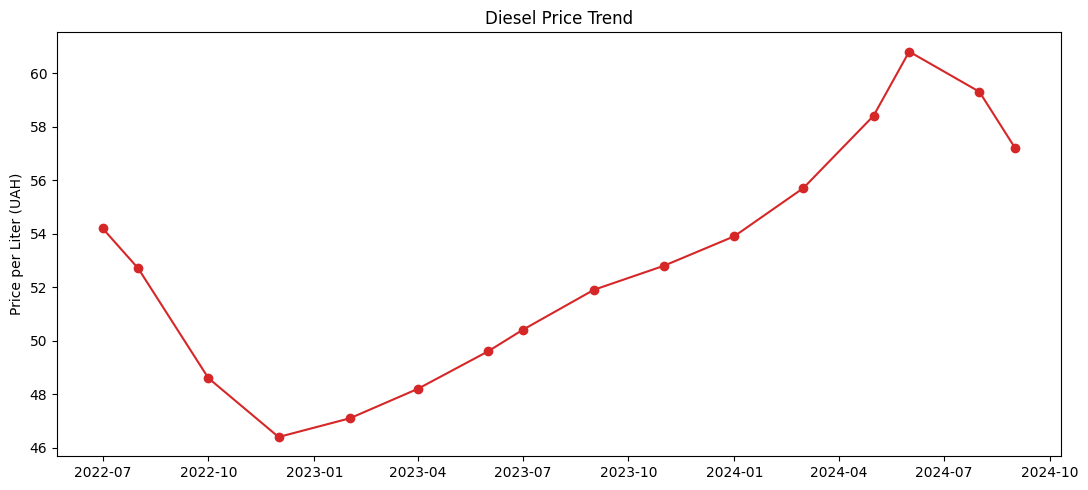

In [5]:
fuel_price_trend = fuel_batches.groupby(
    fuel_batches["purchase_date"].dt.to_period("M").dt.to_timestamp()
)["price_per_liter_uah"].mean()

price_2022 = fuel_batches[fuel_batches["purchase_date"].dt.year == 2022]["price_per_liter_uah"].mean()
price_2024 = fuel_batches[fuel_batches["purchase_date"].dt.year == 2024]["price_per_liter_uah"].mean()
price_increase_pct = (price_2024 - price_2022) / price_2022 * 100

print(f"Average price 2022: {price_2022:.2f} UAH/L")
print(f"Average price 2024: {price_2024:.2f} UAH/L")
print(f"Increase: {price_increase_pct:.1f}%")

fig, ax = plt.subplots()
ax.plot(fuel_price_trend.index, fuel_price_trend.values, marker="o", color="tab:red")
ax.set_ylabel("Price per Liter (UAH)")
ax.set_title("Diesel Price Trend")
plt.tight_layout()
plt.show()


#### Key Finding

Diesel prices followed a V-shaped pattern rather than a steady increase: prices fell through late 2022 and early 2023, reaching a low around Q1 2023, then rose steadily from mid-2023 through April 2024 (a period of the sharpest increase), before easing slightly toward the end of the observation window. The 2022-to-2024 average increase (14.0%) understates the peak-to-trough swing, which is considerably larger.

## 2. Company Performance Trend

Revenue, fuel cost, and gross margin by month, for the full period - already established in `04_business_overview.ipynb`, shown here alongside the fuel price trend for direct visual comparison.

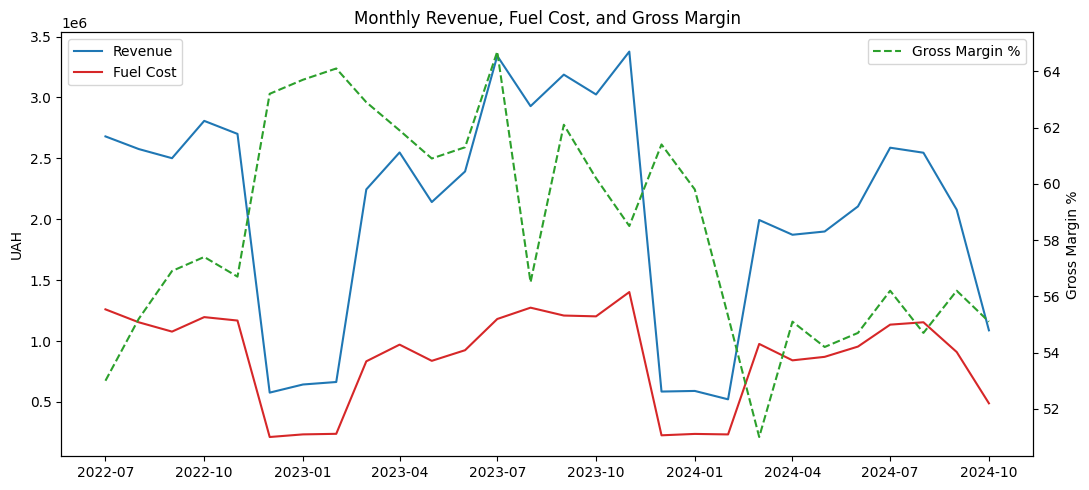

In [6]:
monthly_performance = (
    valid_trips
    .assign(month=valid_trips["date_departure"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(
        revenue_uah=("revenue_uah", "sum"),
        fuel_cost_uah=("fuel_cost_uah", "sum"),
    )
)
monthly_performance["gross_margin_pct"] = (
    (monthly_performance["revenue_uah"] - monthly_performance["fuel_cost_uah"])
    / monthly_performance["revenue_uah"] * 100
).round(1)

fig, ax1 = plt.subplots()
ax1.plot(monthly_performance.index, monthly_performance["revenue_uah"], label="Revenue", color="tab:blue")
ax1.plot(monthly_performance.index, monthly_performance["fuel_cost_uah"], label="Fuel Cost", color="tab:red")
ax1.set_ylabel("UAH")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(monthly_performance.index, monthly_performance["gross_margin_pct"], label="Gross Margin %", color="tab:green", linestyle="--")
ax2.set_ylabel("Gross Margin %")
ax2.legend(loc="upper right")

plt.title("Monthly Revenue, Fuel Cost, and Gross Margin")
plt.tight_layout()
plt.show()

#### Key Finding

Gross margin did not decline alongside the diesel price increase - it fluctuates month to month (roughly 51-65%) but shows no sustained downward trend across the full period. The fuel cost line is also far less volatile than the revenue line, indicating that seasonal swings in business volume, not fuel price movements, are the dominant driver of month-to-month performance. This raises the central question of this notebook: if fuel prices rose but company-level margin held steady, **why?**

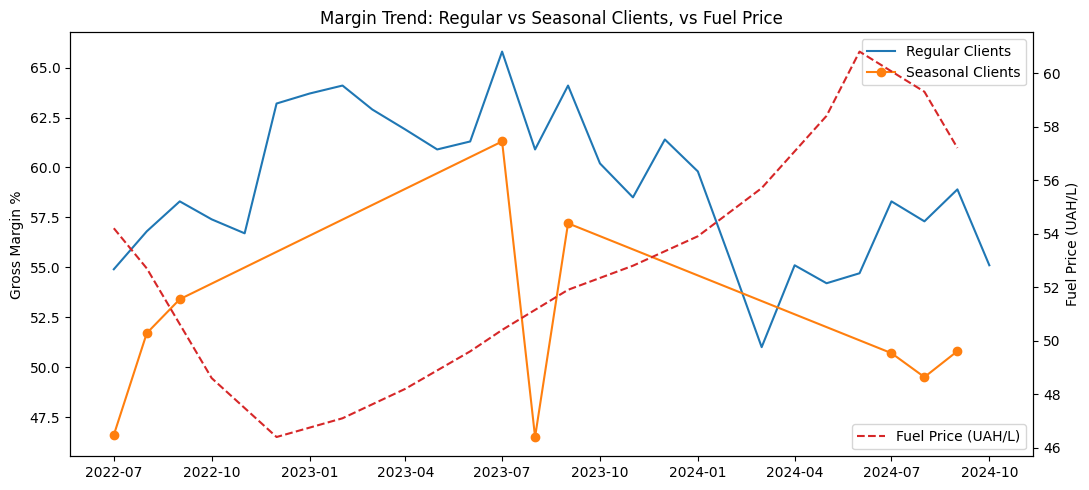

In [7]:
regular_clients = pd.read_sql(
    text("SELECT client_id FROM clients WHERE is_seasonal = 0"),
    engine
)["client_id"]

seasonal_clients = pd.read_sql(
    text("SELECT client_id FROM clients WHERE is_seasonal = 1"),
    engine
)["client_id"]

def monthly_margin(trips_subset):
    m = (
        trips_subset
        .assign(month=trips_subset["date_departure"].dt.to_period("M").dt.to_timestamp())
        .groupby("month")
        .agg(revenue_uah=("revenue_uah", "sum"), fuel_cost_uah=("fuel_cost_uah", "sum"))
    )
    m["gross_margin_pct"] = ((m["revenue_uah"] - m["fuel_cost_uah"]) / m["revenue_uah"] * 100).round(1)
    return m["gross_margin_pct"]

regular_margin_trend = monthly_margin(valid_trips[valid_trips["client_id"].isin(regular_clients)])
seasonal_margin_trend = monthly_margin(valid_trips[valid_trips["client_id"].isin(seasonal_clients)])

fig, ax1 = plt.subplots()
ax1.plot(regular_margin_trend.index, regular_margin_trend.values, label="Regular Clients", color="tab:blue")
ax1.plot(seasonal_margin_trend.index, seasonal_margin_trend.values, label="Seasonal Clients", color="tab:orange", marker="o")
ax1.set_ylabel("Gross Margin %")
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(fuel_price_trend.index, fuel_price_trend.values, color="tab:red", linestyle="--", label="Fuel Price (UAH/L)")
ax2.set_ylabel("Fuel Price (UAH/L)")
ax2.legend(loc="lower right")

plt.title("Margin Trend: Regular vs Seasonal Clients, vs Fuel Price")
plt.tight_layout()
plt.show()

#### Key Finding

Regular and seasonal clients respond very differently to fuel price movements. Regular-client margin remains resilient even at fuel price peaks - it climbs to one of its highest points (~63%) in late 2023/early 2024, exactly when diesel was near its most expensive, consistent with freight rates successfully keeping pace with fuel costs for this segment. Seasonal-client margin is far more volatile: it drops sharply to its lowest point (~47%) mid-2023, and again declines toward the end of the observation window as fuel prices approached their peak - indicating seasonal clients are less protected from fuel price shocks, likely due to shorter, less continuous pricing relationships.

*Note: seasonal-client data points are sparse (active only during harvest months), so the line connecting points spans several months of no activity and should be read as discrete seasonal snapshots rather than a continuous monthly trend.*

## 3. Did Freight Rates Keep Up With Fuel Prices?

Realized rate (revenue per ton-km) compared against the fuel price trend. If freight rates rose roughly in step with fuel prices, that explains why margin held steady despite rising fuel costs.

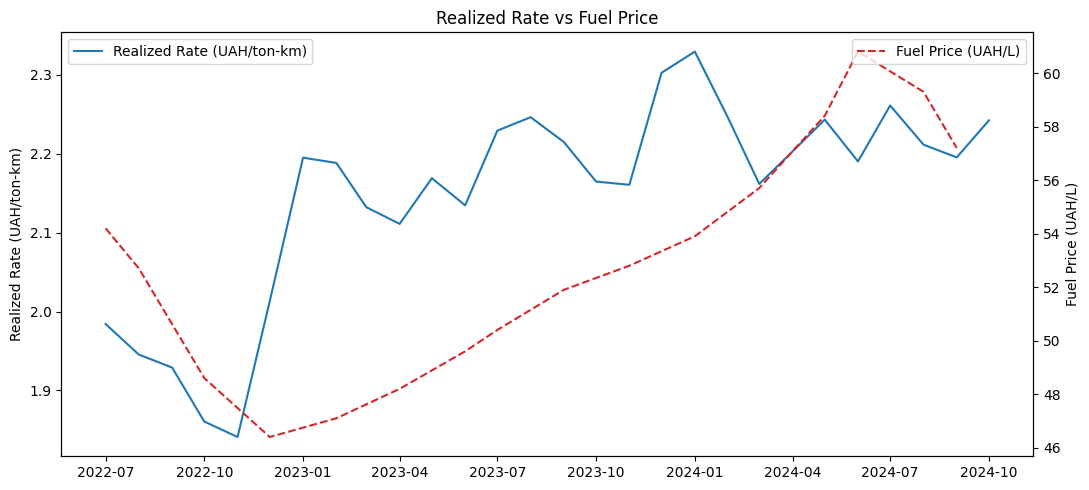

In [8]:
monthly_rate = (
    valid_trips
    .assign(
        month=valid_trips["date_departure"].dt.to_period("M").dt.to_timestamp(),
        realized_rate=valid_trips["revenue_uah"] / (valid_trips["trip_distance_km"] * valid_trips["cargo_tons_actual"])
    )
    .groupby("month")["realized_rate"]
    .mean()
)

fig, ax1 = plt.subplots()
ax1.plot(monthly_rate.index, monthly_rate.values, color="tab:blue", label="Realized Rate (UAH/ton-km)")
ax1.set_ylabel("Realized Rate (UAH/ton-km)")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(fuel_price_trend.index, fuel_price_trend.values, color="tab:red", linestyle="--", label="Fuel Price (UAH/L)")
ax2.set_ylabel("Fuel Price (UAH/L)")
ax2.legend(loc="upper right")

plt.title("Realized Rate vs Fuel Price")
plt.tight_layout()
plt.show()

#### Key Finding

Realized rate rose earlier and more sharply than fuel prices - the largest tariff increase occurred in late 2022, while diesel prices were still falling, indicating the company raised rates proactively rather than reactively chasing fuel costs. From mid-2023 through early 2024, realized rate continued climbing in step with rising fuel prices. 

However, in the second half of 2024 this alignment weakens: realized rate becomes noticeably more volatile and does not keep the same clear upward pace as fuel prices approach and hold near their peak - a signal that pricing discipline may have softened just as fuel cost pressure was at its highest, and worth monitoring going forward.

In [9]:
rate_2022 = valid_trips[valid_trips["date_departure"].dt.year == 2022].assign(
    realized_rate=lambda d: d["revenue_uah"] / (d["trip_distance_km"] * d["cargo_tons_actual"])
)["realized_rate"].mean()

rate_2024 = valid_trips[valid_trips["date_departure"].dt.year == 2024].assign(
    realized_rate=lambda d: d["revenue_uah"] / (d["trip_distance_km"] * d["cargo_tons_actual"])
)["realized_rate"].mean()

rate_increase_pct = (rate_2024 - rate_2022) / rate_2022 * 100

print(f"Realized rate 2022: {rate_2022:.2f} UAH/ton-km")
print(f"Realized rate 2024: {rate_2024:.2f} UAH/ton-km")
print(f"Rate increase: {rate_increase_pct:.1f}%")
print(f"Fuel price increase: {price_increase_pct:.1f}%")

Realized rate 2022: 1.92 UAH/ton-km
Realized rate 2024: 2.22 UAH/ton-km
Rate increase: 15.6%
Fuel price increase: 14.0%


**Sanity check - is this a real rate increase, or a shift in the client/route mix?** If the route-type mix (local vs highway) stayed roughly stable across the period, the rate increase reflects genuine repricing, not a change in what the company happened to be hauling.

In [10]:
route_mix_early = valid_trips[valid_trips["date_departure"].dt.year == 2022]["route_type"].value_counts(normalize=True).round(2)
route_mix_late = valid_trips[valid_trips["date_departure"].dt.year == 2024]["route_type"].value_counts(normalize=True).round(2)

pd.DataFrame({"2022": route_mix_early, "2024": route_mix_late})

,2022,2024
route_type,,
highway,0.58,0.63
local,0.42,0.37


In [11]:
h2_2024_rate = monthly_rate[monthly_rate.index >= "2024-04"]
h2_2024_fuel = fuel_price_trend[fuel_price_trend.index >= "2024-04"]

rate_change_h2 = (h2_2024_rate.iloc[-1] - h2_2024_rate.iloc[0]) / h2_2024_rate.iloc[0] * 100
fuel_change_h2 = (h2_2024_fuel.iloc[-1] - h2_2024_fuel.iloc[0]) / h2_2024_fuel.iloc[0] * 100

print(f"Realized rate change (Apr-Oct 2024): {rate_change_h2:.1f}%")
print(f"Fuel price change (Apr-Oct 2024): {fuel_change_h2:.1f}%")

Realized rate change (Apr-Oct 2024): 1.8%
Fuel price change (Apr-Oct 2024): -2.1%


#### Key Finding

Realized rate rose 15.6% from 2022 to 2024, slightly outpacing the 14.0% increase in fuel prices - freight rates did not just keep up with fuel costs, they modestly exceeded them.

The route-type mix shifted modestly over the same period: highway trips grew from 58% to 63% of volume, local trips declined from 42% to 37%. This is a small shift, not a dramatic restructuring, so it does not fully explain the 15.6% rate increase - but it does mean part of that increase may reflect a slightly higher-paying mix (more highway trips) rather than pure price increases on the same routes. The rate increase is most likely a combination of genuine repricing and a modest shift toward longer-distance business, not one cause alone.

In the second half of 2024 specifically, realized rate continued rising (+1.8%) even as fuel prices eased (-2.1%) from their peak - the earlier-observed volatility in this period reflects fuel price correction rather than any weakening in pricing discipline.


## 4. Client Fuel Exposure

Fuel Intensity (liters per 1,000 UAH of revenue) identifies which clients are most exposed to further fuel price increases, regardless of their current tariff or margin. Limited to clients active in 2024, consistent with `05_client_profitability.ipynb`.

In [12]:
trips_2024 = trips[trips["date_departure"].dt.year == 2024]
valid_2024 = trips_2024.dropna(subset=["revenue_uah", "fuel_cost_uah", "estimated_fuel_liters"])

client_fuel_risk = (
    valid_2024
    .groupby(["client_id", "client_name"])
    .agg(
        trip_count=("trip_id", "count"),
        total_liters=("estimated_fuel_liters", "sum"),
        revenue_uah=("revenue_uah", "sum"),
        fuel_cost_uah=("fuel_cost_uah", "sum"),
    )
)
client_fuel_risk["fuel_intensity_l_per_1000uah"] = (
    client_fuel_risk["total_liters"] / client_fuel_risk["revenue_uah"] * 1000
).round(2)
client_fuel_risk["gross_margin_pct"] = (
    (client_fuel_risk["revenue_uah"] - client_fuel_risk["fuel_cost_uah"]) / client_fuel_risk["revenue_uah"] * 100
).round(1)

client_fuel_risk = client_fuel_risk.reset_index().sort_values("fuel_intensity_l_per_1000uah", ascending=False)

client_fuel_risk[
    ["client_name", "trip_count", "revenue_uah", "fuel_intensity_l_per_1000uah", "gross_margin_pct"]
]

,client_name,trip_count,revenue_uah,fuel_intensity_l_per_1000uah,gross_margin_pct
9,ТОВ Нива Експорт,90,7.608691e+05,9.46,43.8
2,ТОВ Полтавські Лани,167,4.141124e+06,8.50,50.3
3,ФГ Кукурудза Південь,107,6.616704e+05,8.28,52.5
1,ПП ДніпроЗерно,192,3.889903e+06,8.21,52.3
8,ФГ Золоте Колосся,100,5.162626e+05,7.98,52.7
6,ФГ Жнива-Поділля,93,2.230247e+05,7.95,53.0
7,ТОВ Пшеничний Шлях,108,7.590143e+05,7.69,54.3
5,АгроЛогістика Центр,184,2.537897e+06,6.99,59.2
0,ТОВ Соняшник-Агро,227,3.064563e+06,6.60,61.6
4,ТОВ Соєвий Дім,94,7.281712e+05,5.58,67.5


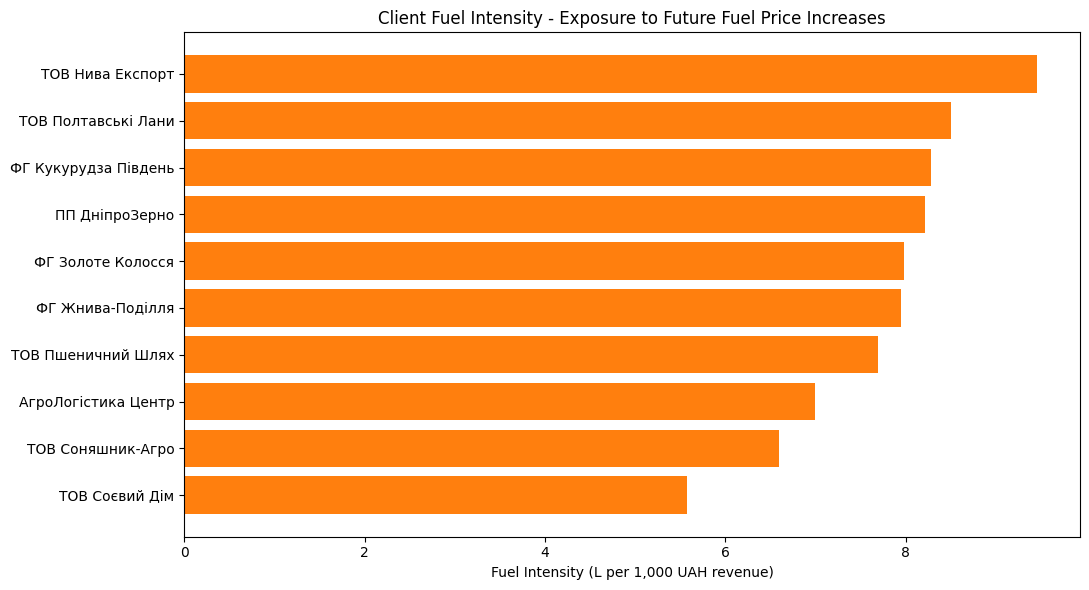

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

sorted_clients = client_fuel_risk.sort_values("fuel_intensity_l_per_1000uah", ascending=True)
ax.barh(sorted_clients["client_name"], sorted_clients["fuel_intensity_l_per_1000uah"], color="tab:orange")
ax.set_xlabel("Fuel Intensity (L per 1,000 UAH revenue)")
ax.set_title("Client Fuel Intensity - Exposure to Future Fuel Price Increases")
plt.tight_layout()
plt.show()

In [14]:
client_tariff = (
    valid_2024
    .assign(effective_rate=valid_2024["revenue_uah"] / (valid_2024["trip_distance_km"] * valid_2024["cargo_tons_actual"]))
    .groupby(["client_id", "client_name"])["effective_rate"]
    .mean()
    .round(2)
    .reset_index()
)

client_fuel_risk = client_fuel_risk.merge(client_tariff, on=["client_id", "client_name"])

client_fuel_risk[
    ["client_name", "fuel_intensity_l_per_1000uah", "effective_rate", "gross_margin_pct"]
].sort_values("fuel_intensity_l_per_1000uah", ascending=False)

,client_name,fuel_intensity_l_per_1000uah,effective_rate,gross_margin_pct
0,ТОВ Нива Експорт,9.46,1.94,43.8
1,ТОВ Полтавські Лани,8.50,1.87,50.3
2,ФГ Кукурудза Південь,8.28,2.11,52.5
3,ПП ДніпроЗерно,8.21,1.98,52.3
4,ФГ Золоте Колосся,7.98,2.07,52.7
5,ФГ Жнива-Поділля,7.95,2.11,53.0
6,ТОВ Пшеничний Шлях,7.69,2.17,54.3
7,АгроЛогістика Центр,6.99,2.40,59.2
8,ТОВ Соняшник-Агро,6.60,2.54,61.6
9,ТОВ Соєвий Дім,5.58,2.95,67.5


#### Key Finding

The three clients with the highest fuel intensity - ТОВ Нива Експорт (9.46), ТОВ Полтавські Лани (8.50), and ФГ Кукурудза Південь (8.28) - also carry the lowest effective rates (1.94, 1.87, 2.11 UAH/ton-km) and the lowest margins (43.8%, 50.3%, 52.5%). This is a compounded exposure: these clients are both physically fuel-heavy per unit of revenue *and* underpriced relative to peers, making them the most vulnerable to further fuel price increases.

At the other end, ТОВ Соєвий Дім and ТОВ Соняшник-Агро combine the lowest fuel intensity (5.58, 6.60) with the highest effective rates (2.95, 2.54) and highest margins (67.5%, 61.6%) - the best-insulated clients in the portfolio.

Across the full client base, fuel intensity, effective rate, and margin move together almost without exception - in this dataset, where fuel is the only cost factor modeled, low fuel intensity and adequate pricing reinforce each other rather than acting as independent, separable risks.

*Note: because this dataset models fuel as the only cost component, the tight alignment between fuel intensity, rate, and margin is expected. In a business with a fuller cost structure, these three measures would likely diverge more, making the distinction between "physically fuel-heavy" and "underpriced" more meaningful.*

## 5. Route Fuel Exposure

**Purpose:** identify routes with the highest fuel intensity.

**Out of scope:** operational root causes (idling, delays, traffic, loading time) are analyzed in `07_route_analysis.ipynb`. This section answers *where* exposure is concentrated, not *why*.


In [15]:
route_fuel_risk = (
    valid_2024
    .groupby("route_type")
    .agg(
        trip_count=("trip_id", "count"),
        total_liters=("estimated_fuel_liters", "sum"),
        revenue_uah=("revenue_uah", "sum"),
        fuel_cost_uah=("fuel_cost_uah", "sum"),
        avg_distance_km=("trip_distance_km", "mean"),
    )
)
route_fuel_risk["fuel_intensity_l_per_1000uah"] = (
    route_fuel_risk["total_liters"] / route_fuel_risk["revenue_uah"] * 1000
).round(2)
route_fuel_risk["gross_margin_pct"] = (
    (route_fuel_risk["revenue_uah"] - route_fuel_risk["fuel_cost_uah"]) / route_fuel_risk["revenue_uah"] * 100
).round(1)

route_fuel_risk.reset_index().sort_values("fuel_intensity_l_per_1000uah", ascending=False)

,route_type,trip_count,total_liters,revenue_uah,fuel_cost_uah,avg_distance_km,fuel_intensity_l_per_1000uah,gross_margin_pct
0,highway,860,112339.04,1.439436e+07,6552301.06,368.672093,7.80,54.5
1,local,502,21273.64,2.888143e+06,1246733.56,114.231076,7.37,56.8


#### Key Finding

At the route-type level, fuel exposure is nearly identical between highway and local routes (7.80 vs 7.37 L per 1,000 UAH revenue) - a difference of only 5.5%, consistent with the weak route-type effect already observed in `05_client_profitability.ipynb`. Route type alone does not meaningfully differentiate fuel exposure; the client-level analysis above is a far stronger signal of where exposure is concentrated. Any further route-level investigation should focus on specific routes (e.g. individual origin-destination pairs, as identified for structural-risk clients in `05_client_profitability.ipynb`) rather than the broad highway/local split, and is deferred to `07_route_analysis.ipynb`.

## Key Findings

- Diesel prices rose 14.0% from 2022 to 2024 on average, but followed a V-shaped pattern rather than a steady increase - falling through late 2022/early 2023, then rising sharply from mid-2023 through April 2024, before easing slightly toward the end of the period.
- Company-level gross margin did not decline alongside fuel prices - it fluctuated between roughly 51% and 65% with no sustained downward trend. Revenue shows far greater month-to-month volatility than fuel cost, indicating seasonal demand swings, not fuel price movements, are the dominant driver of business performance fluctuations.
- Freight rates rose 15.6% over the same period, slightly outpacing the 14.0% fuel price increase - the company did not just keep up with rising fuel costs, it modestly exceeded them through repricing.
- This rate increase reflects a mix of genuine repricing and a modest shift in route composition: highway trips grew from 58% to 63% of volume, so part of the increase may reflect a higher-paying mix rather than pure price increases on the same routes.
- In the second half of 2024, realized rate continued rising (+1.8%) even as fuel prices eased (-2.1%) from their peak - this reflects fuel price correction, not a weakening of pricing discipline.
- Regular and seasonal clients responded very differently to fuel price movements. Regular-client margin stayed resilient even at fuel price peaks (reaching ~63% in late 2023/early 2024), while seasonal-client margin was far more volatile, dropping to ~47% mid-2023 and declining again as fuel prices approached their peak.
- Fuel exposure is concentrated in specific clients, not spread evenly: ТОВ Нива Експорт, ТОВ Полтавські Лани, and ФГ Кукурудза Південь combine the highest fuel intensity with the lowest effective rates and the lowest margins in the portfolio - a compounded exposure to further fuel price increases. ТОВ Соєвий Дім and ТОВ Соняшник-Агро are the best-insulated, combining low fuel intensity with the highest rates and margins.
- Route type is a weak differentiator of fuel exposure (highway 7.80 vs local 7.37 L per 1,000 UAH revenue, a 5.5% difference) - consistent with the weak route-type effect already found in `05_client_profitability.ipynb`. Client-specific factors, not broad route-type categories, drive fuel exposure.

## Business Recommendations

- Continue the current pricing discipline - freight rate increases have outpaced fuel cost increases, and this proactive repricing approach should remain the primary lever for managing fuel cost pressure, rather than reactive adjustments after margin erodes.
- Prioritize ТОВ Нива Експорт, ТОВ Полтавські Лани, and ФГ Кукурудза Південь for tariff review with fuel cost pass-through clauses - these three clients carry compounded exposure (high fuel intensity and below-market rates) and are most vulnerable to further fuel price increases.
- Extend seasonal client contracts to include fuel cost escalation clauses - seasonal clients showed the most volatile margin response to fuel price swings and the least pricing protection of the two client segments.
- Monitor the route-type mix going forward - the modest shift toward highway trips (58% to 63%) partially drove the recent rate increase; a further shift could either reinforce or undermine future pricing power depending on direction.
- Route-type category alone is not a useful lens for fuel risk management - any further operational investigation should target specific routes and their delay/idle-time profiles, covered in `07_route_analysis.ipynb`, rather than broad highway/local distinctions.

## Save Client Fuel Risk Dataset

Two datasets are saved: `client_fuel_risk` (client-level exposure, 2024) and `fuel_price_trend` (monthly diesel price, full period) — both feed the Tableau Fuel Cost Analysis dashboard.

In [16]:
output_path = Path("../data/processed/client_fuel_risk.csv")
client_fuel_risk.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Saved: ../data/processed/client_fuel_risk.csv


In [17]:
client_fuel_risk.to_sql("client_fuel_risk", engine, if_exists="replace", index=False)
print("client_fuel_risk written to MySQL.")

client_fuel_risk written to MySQL.


In [18]:
fuel_price_export = fuel_price_trend.reset_index()
fuel_price_export.columns = ["month", "price_per_liter_uah"]

fuel_price_export.to_csv("../data/processed/fuel_price_trend.csv", index=False)
print(f"Saved: ../data/processed/fuel_price_trend.csv")

Saved: ../data/processed/fuel_price_trend.csv


## Summary

Rising diesel prices (14.0% increase, 2022-2024, following a V-shaped rather than steady trend) did not become critical for business viability. Company-level gross margin held steady because freight rates rose slightly faster (15.6%) than fuel costs, through a combination of genuine repricing and a modest shift toward higher-paying highway routes. This pricing discipline held even through the H2 2024 period where realized rate and fuel price temporarily diverged - a fuel price correction, not a breakdown in pricing.

However, this resilience is uneven: seasonal clients show far more fuel-price-sensitive margin than regular clients, and a small group of clients (ТОВ Нива Експорт, ТОВ Полтавські Лани, ФГ Кукурудза Південь) carry compounded exposure - high fuel intensity paired with below-market rates - making them the most vulnerable to any further fuel price increases. Route type itself is not a meaningful risk factor; exposure is concentrated at the client level.

Output: `client_fuel_risk` (MySQL table and `data/processed/client_fuel_risk.csv`) for the Tableau Fuel Cost Analysis

